# Results Checking

Thorough audit of the result files: **coverage** (what the config says should exist vs. what's on disk), **completeness** (folds < `cv_splits`, malformed files), **sanity** (NaN / out-of-range / worse-than-random metrics), **stale** files, and **visualisations** (dataset×method coverage heatmaps, fold completeness, metric distributions, sweep curves).

All logic lives in [`src/utils/results_checking.py`](../src/utils/results_checking.py); this notebook is a thin viewer. It transparently handles **both** result layouts: one file per `(dataset, method)` point (Experiment 0/1), and **packed** files where all of a cell's sweep points live in a single `<method>.json` (Experiment 2/3, metrics only — no prediction arrays).

> **Where to run:** wherever the results live. On the cluster the results are on the Lustre **project storage** (`/staging/leuven/stg_00211/results`), which the OnDemand *file browser* cannot see — open a **VSCode session in OnDemand** (it *can* see Lustre) and run this notebook there, or run it locally against a downloaded copy. Set `RESULTS_ROOT` below accordingly.

In [1]:
import sys
from pathlib import Path

# Make `import src.*` work when running from the notebooks/ folder.
_REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from src.utils import results_checking as rc
from src.utils.paths import results_root

# None -> auto-resolve ($TABPFN_RESULTS_ROOT / project-storage / ./results).
# On the cluster you can pin it explicitly, e.g.:
#   RESULTS_ROOT = '/staging/leuven/stg_00211/results'
RESULTS_ROOT = None
print('Results root:', RESULTS_ROOT or results_root())

Results root: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results


## 1. One-call overview (all experiments)

Headline tables + plots for every experiment. Drill into any one in the sections below.

  Experiment0
results root: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results



,count
check,
expected (from config),854
present on disk,854
complete (>= cv folds),854
"MISSING (expected, absent)",0
INCOMPLETE (< cv folds),0
MALFORMED / unreadable,0
ANOMALOUS metrics,7
"STALE (on disk, not in config)",0



-- 7 ANOMALOUS (showing up to 30) --
task           dataset      name base_method                            issues
 lgd   0004.base_model      dnnr        dnnr         R2 very negative (-1.623)
  pd         0001.gmsc     ptarl       ptarl AUC<0.5 worse-than-random (0.292)
  pd 0003.vehicle_loan     ptarl       ptarl AUC<0.5 worse-than-random (0.492)
  pd 0011.loan_default modernNCA   modernNCA AUC<0.5 worse-than-random (0.480)
  pd 0011.loan_default     ptarl       ptarl AUC<0.5 worse-than-random (0.479)
  pd  0012.home_credit   tabcaps     tabcaps AUC<0.5 worse-than-random (0.469)
  pd  0012.home_credit    tabnet      tabnet AUC<0.5 worse-than-random (0.486)


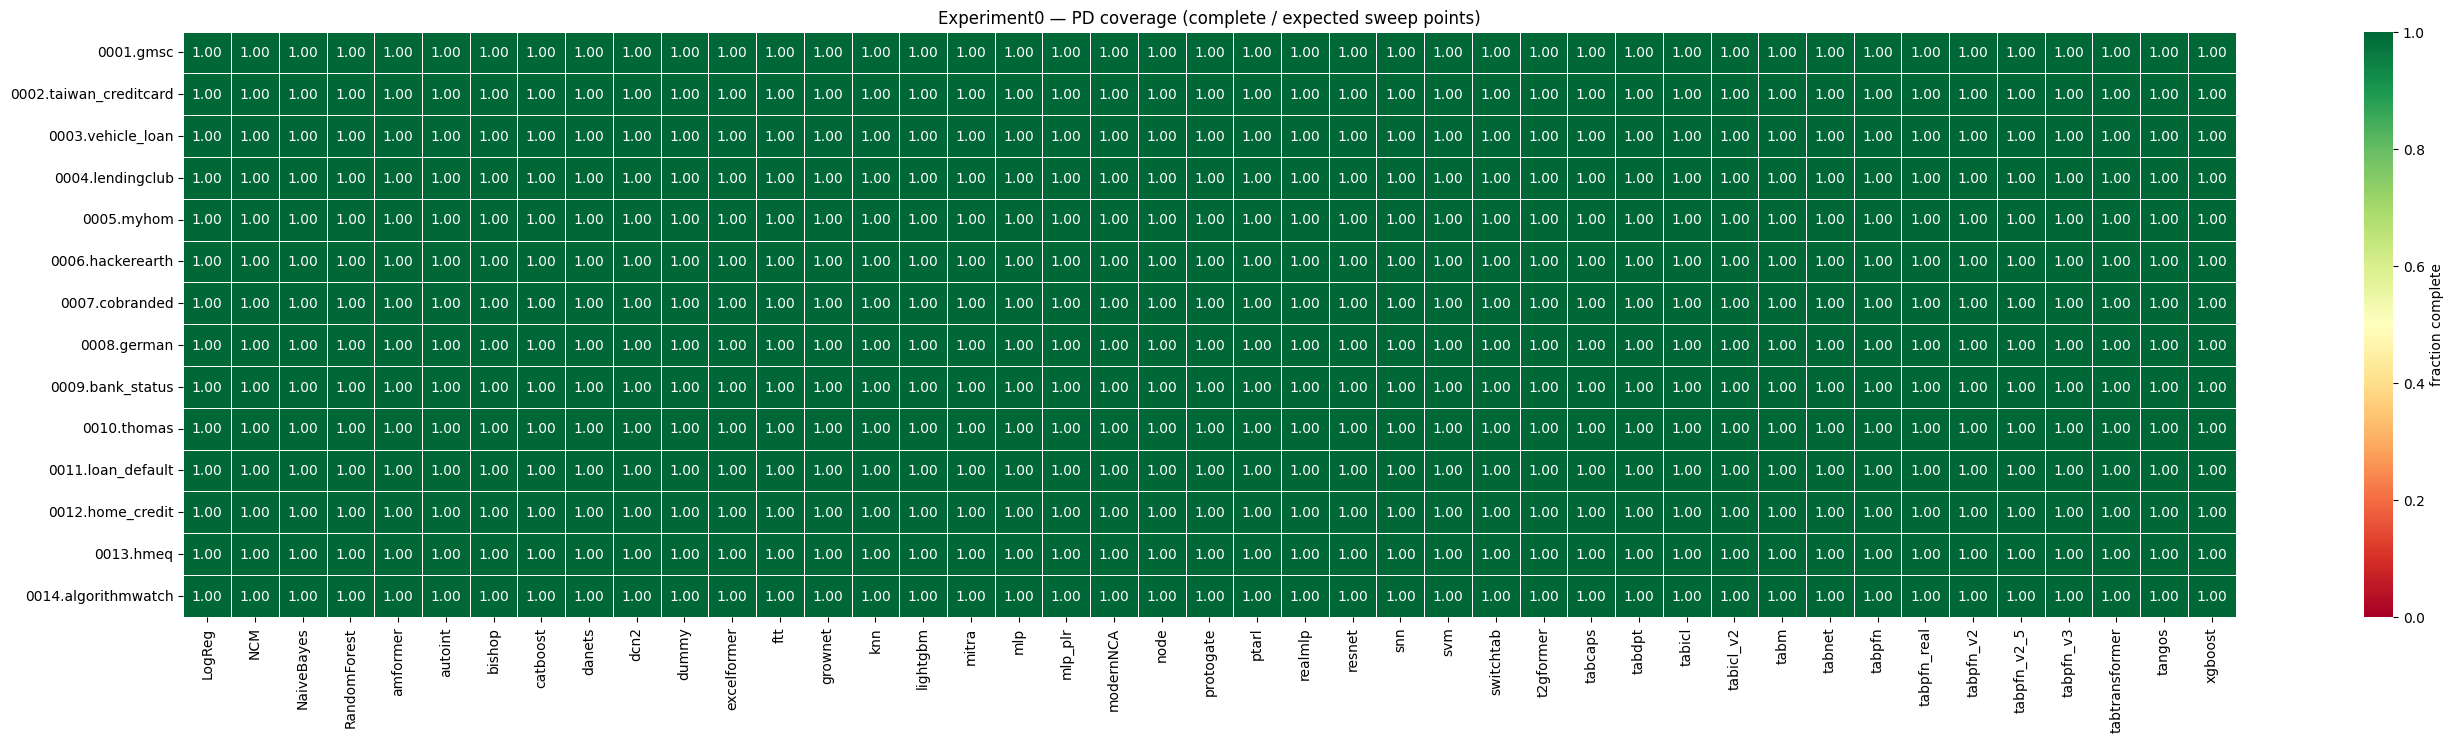

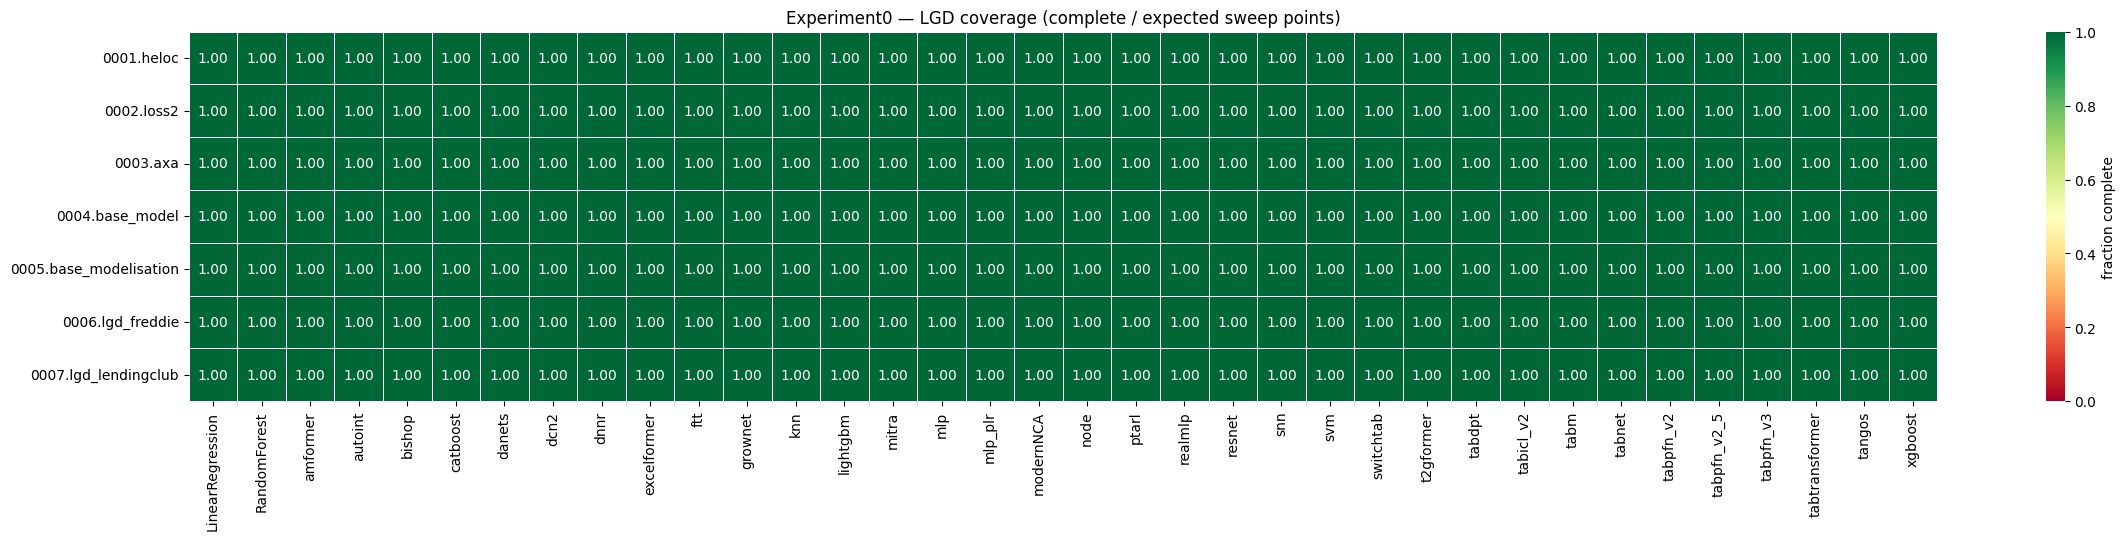

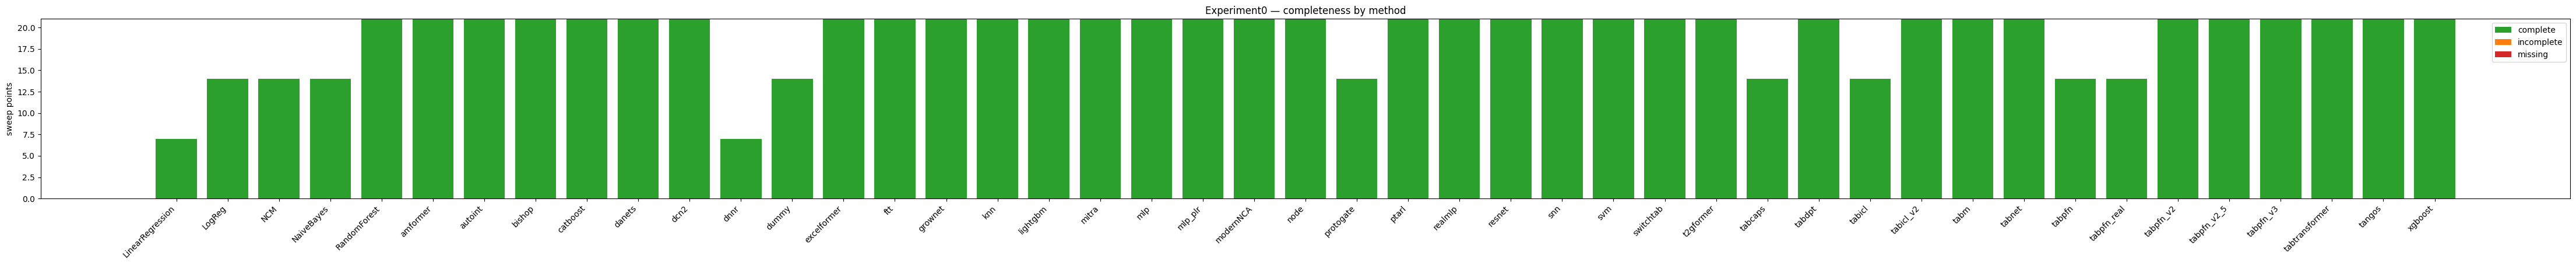

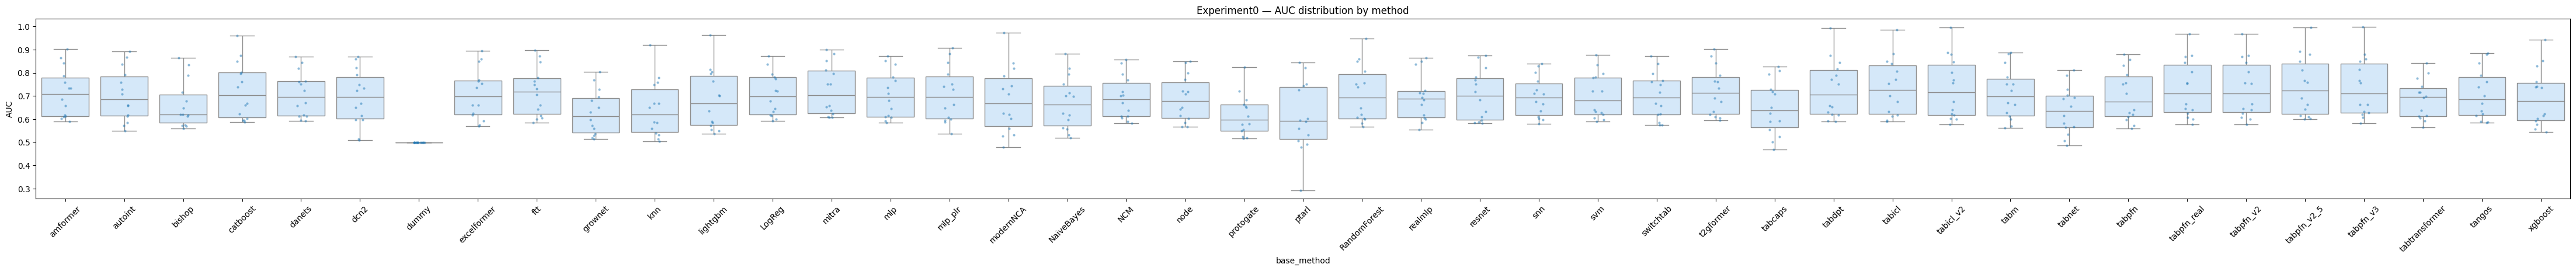


  Experiment1
results root: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results



,count
check,
expected (from config),1316
present on disk,1277
complete (>= cv folds),1277
"MISSING (expected, absent)",39
INCOMPLETE (< cv folds),0
MALFORMED / unreadable,0
ANOMALOUS metrics,1
"STALE (on disk, not in config)",0



-- 39 MISSING (showing up to 30) --
task                dataset           name base_method
 lgd             0001.heloc        autoint     autoint
 lgd             0001.heloc   autoint__HPO     autoint
 lgd             0002.loss2        autoint     autoint
 lgd             0002.loss2   autoint__HPO     autoint
 lgd               0003.axa        autoint     autoint
 lgd               0003.axa   autoint__HPO     autoint
 lgd        0004.base_model        autoint     autoint
 lgd        0004.base_model   autoint__HPO     autoint
 lgd 0005.base_modelisation        autoint     autoint
 lgd 0005.base_modelisation   autoint__HPO     autoint
 lgd       0006.lgd_freddie        autoint     autoint
 lgd       0006.lgd_freddie   autoint__HPO     autoint
 lgd   0007.lgd_lendingclub        autoint     autoint
 lgd   0007.lgd_lendingclub   autoint__HPO     autoint
  pd             0005.myhom        autoint     autoint
  pd             0005.myhom   autoint__HPO     autoint
  pd       0006.hackerearth 

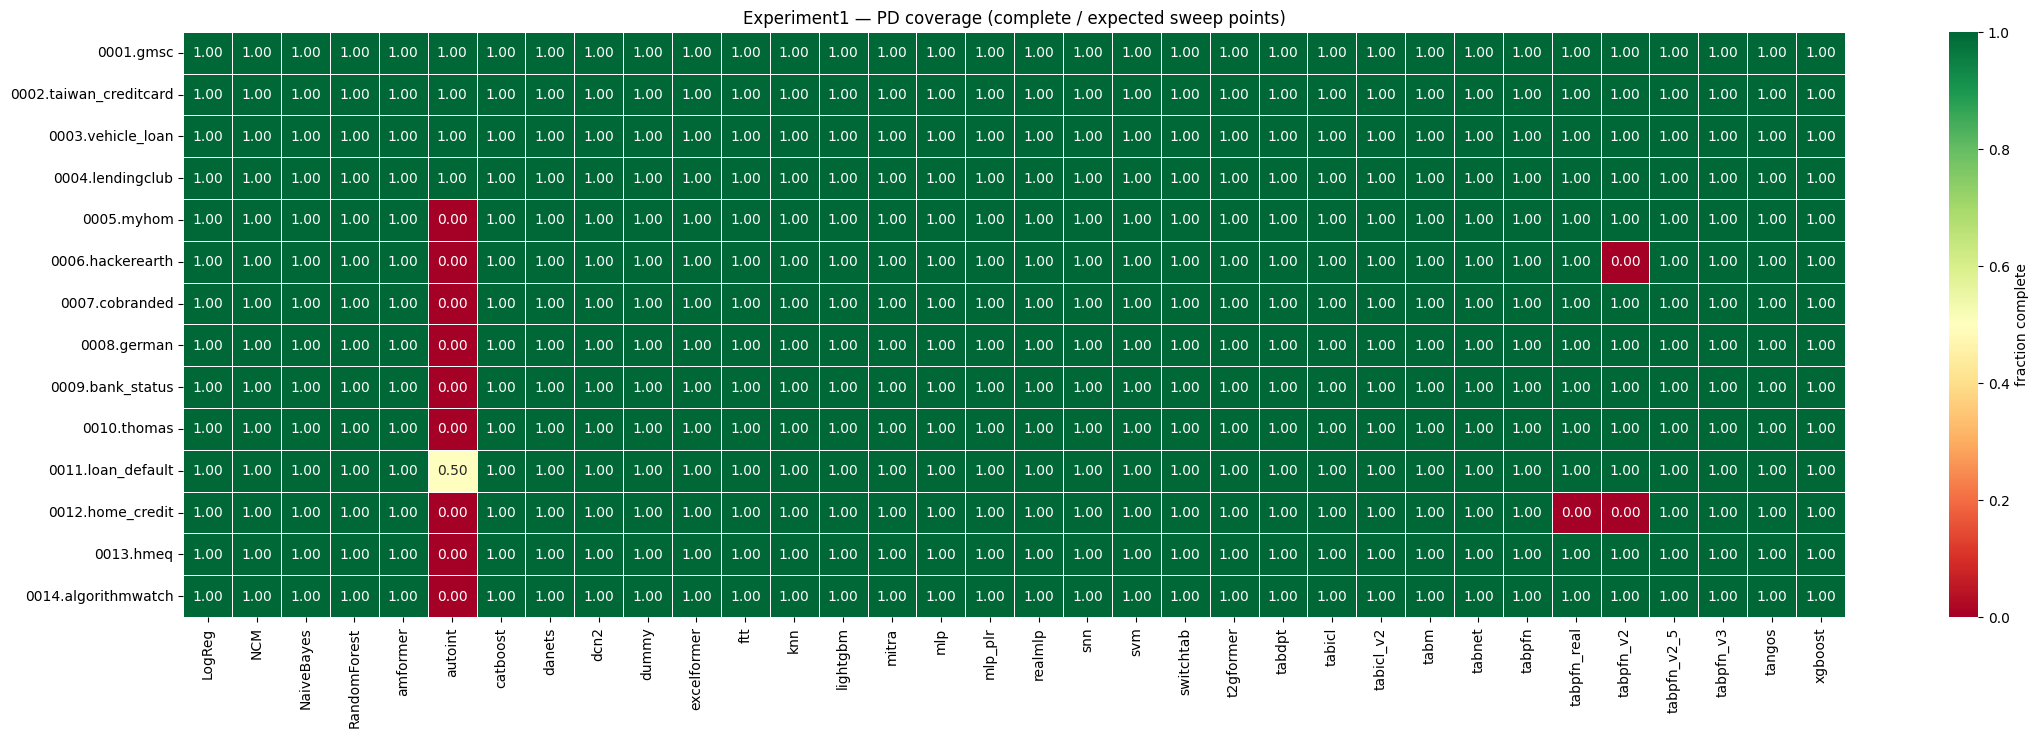

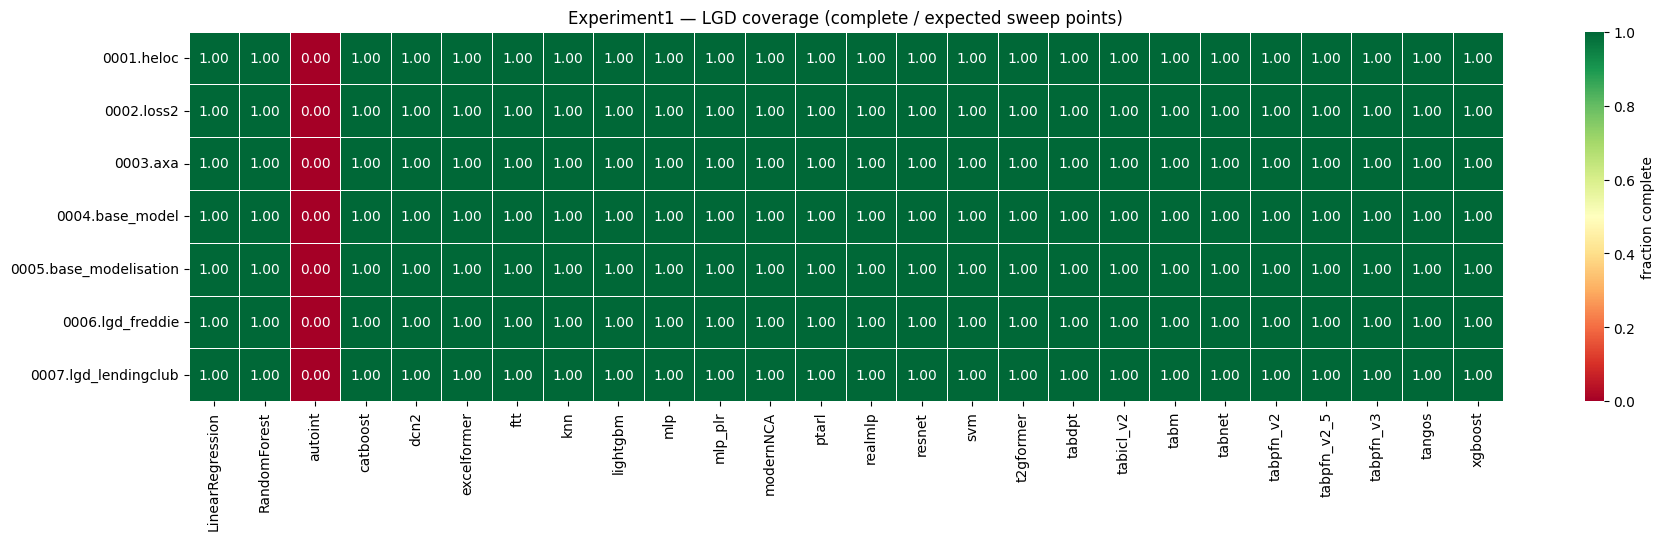

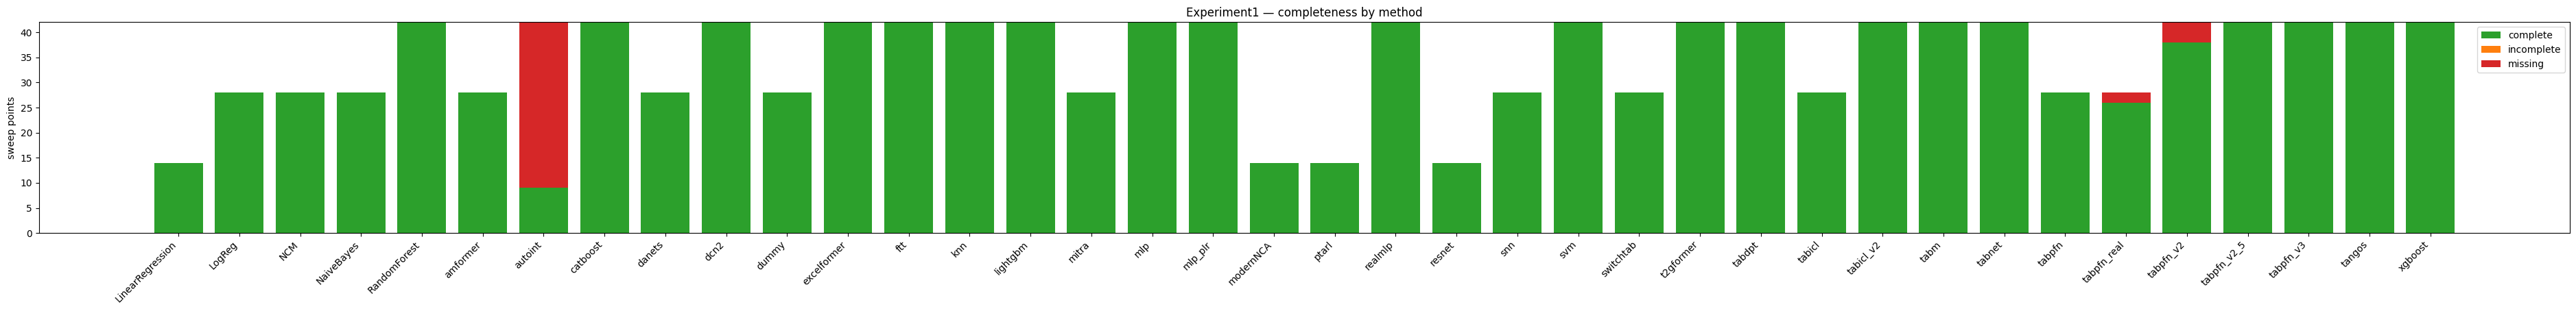

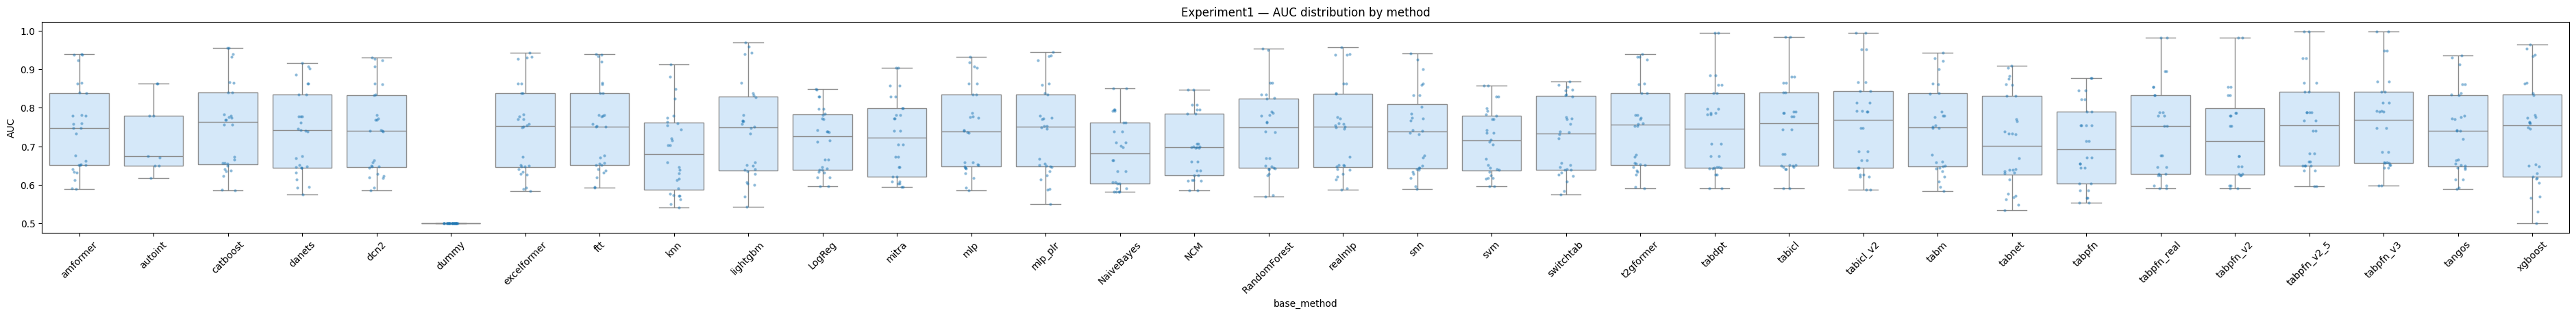


  Experiment2
results root: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results



,count
check,
expected (from config),48852
present on disk,26249
complete (>= cv folds),26249
"MISSING (expected, absent)",22603
INCOMPLETE (< cv folds),0
MALFORMED / unreadable,0
ANOMALOUS metrics,14
"STALE (on disk, not in config)",0



-- 22603 MISSING (showing up to 30) --
task    dataset               name base_method
 lgd 0001.heloc tabicl_v2__row1000   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1010   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1020   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1030   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1040   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1050   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1060   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1070   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1080   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1090   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1100   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1110   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1120   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1130   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1140   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1150   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1160   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1170   tabicl_v2
 lgd 0001.heloc tabicl_v2__row1180   tabicl_v2
 lgd 0001.heloc tabi

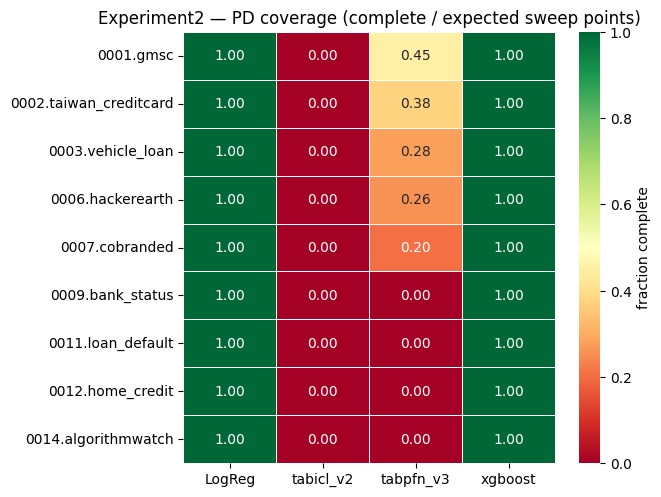

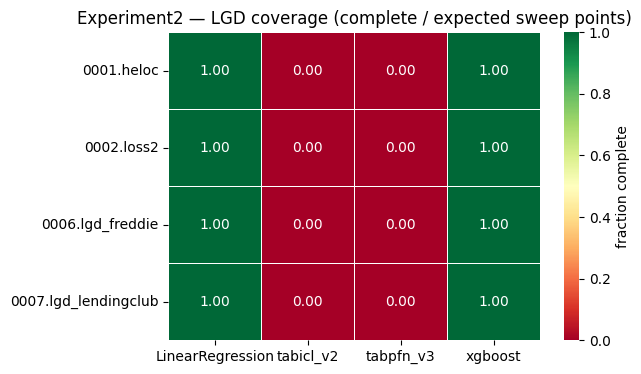

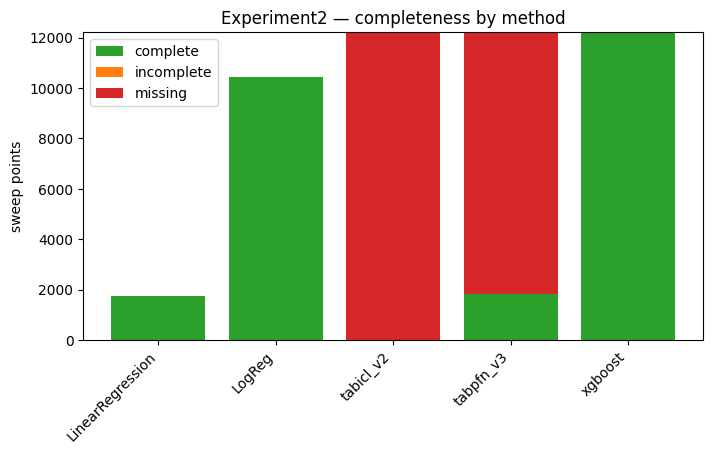

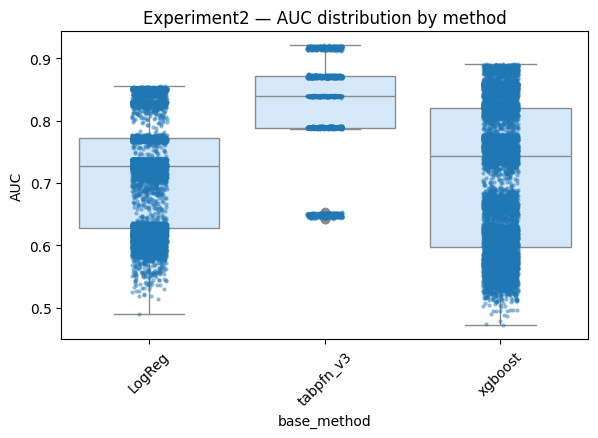

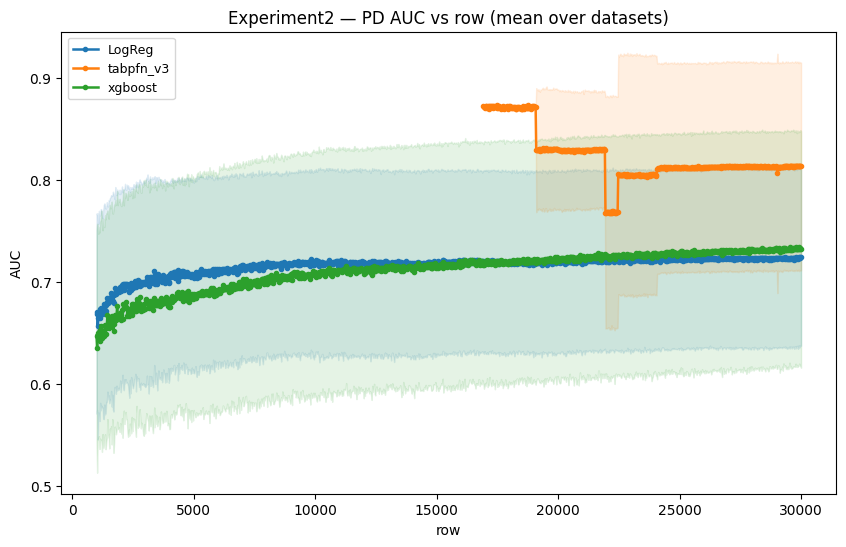

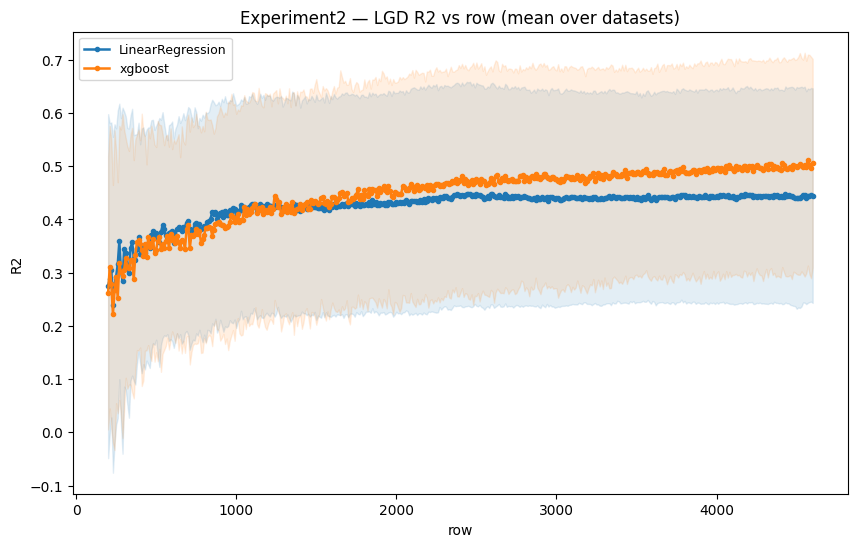


  Experiment3
results root: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results



,count
check,
expected (from config),7104
present on disk,3552
complete (>= cv folds),3552
"MISSING (expected, absent)",3552
INCOMPLETE (< cv folds),0
MALFORMED / unreadable,0
ANOMALOUS metrics,0
"STALE (on disk, not in config)",0



-- 3552 MISSING (showing up to 30) --
task                dataset                 name base_method
  pd 0002.taiwan_creditcard tabicl_v2__min0p0025   tabicl_v2
  pd 0002.taiwan_creditcard  tabicl_v2__min0p003   tabicl_v2
  pd 0002.taiwan_creditcard tabicl_v2__min0p0035   tabicl_v2
  pd 0002.taiwan_creditcard  tabicl_v2__min0p004   tabicl_v2
  pd 0002.taiwan_creditcard tabicl_v2__min0p0045   tabicl_v2
  pd 0002.taiwan_creditcard  tabicl_v2__min0p005   tabicl_v2
  pd 0002.taiwan_creditcard tabicl_v2__min0p0055   tabicl_v2
  pd 0002.taiwan_creditcard  tabicl_v2__min0p006   tabicl_v2
  pd 0002.taiwan_creditcard tabicl_v2__min0p0065   tabicl_v2
  pd 0002.taiwan_creditcard  tabicl_v2__min0p007   tabicl_v2
  pd 0002.taiwan_creditcard tabicl_v2__min0p0075   tabicl_v2
  pd 0002.taiwan_creditcard  tabicl_v2__min0p008   tabicl_v2
  pd 0002.taiwan_creditcard tabicl_v2__min0p0085   tabicl_v2
  pd 0002.taiwan_creditcard  tabicl_v2__min0p009   tabicl_v2
  pd 0002.taiwan_creditcard tabicl_v2__min0p00

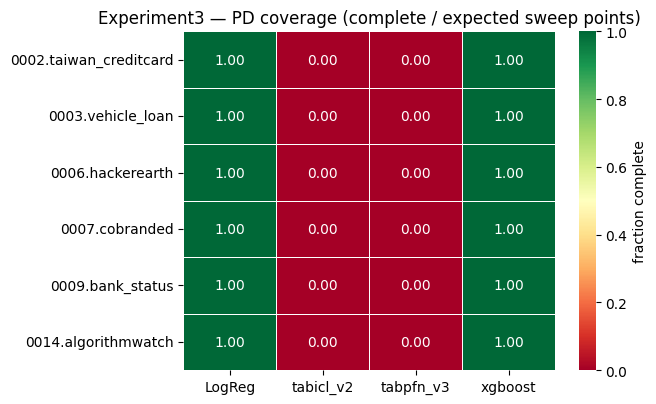

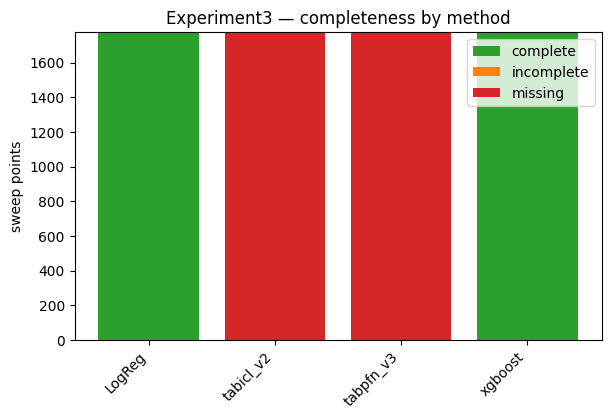

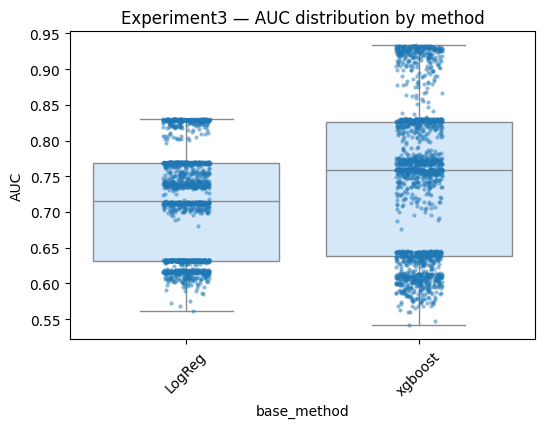

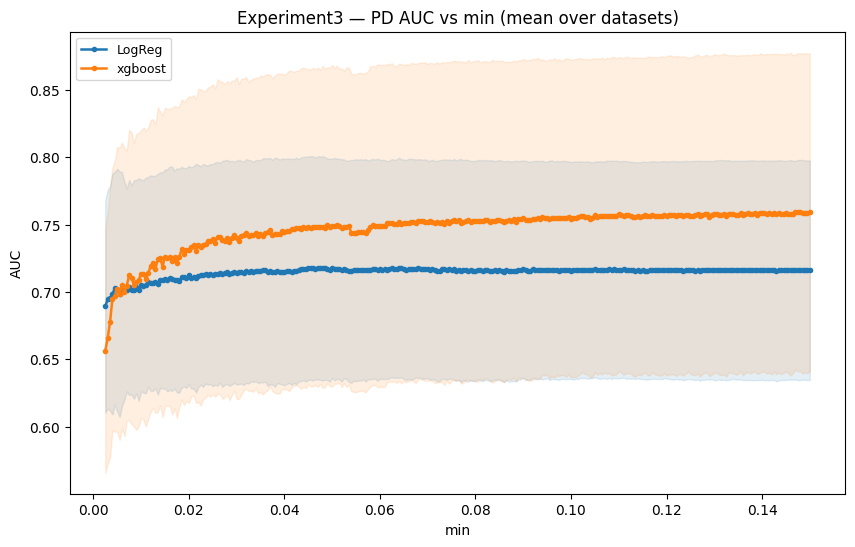

In [2]:
audits = rc.run_full_audit(
    experiments=('Experiment0', 'Experiment1', 'Experiment2', 'Experiment3'),
    results_root=RESULTS_ROOT,
    show_plots=True,
)

## 2. Drill into one experiment

Set `EXP` and re-run the cells below.

In [3]:
EXP = 'Experiment2'
audit = rc.audit_experiment(EXP, results_root=RESULTS_ROOT)
audit.summary()

,count
check,
expected (from config),48852
present on disk,26249
complete (>= cv folds),26249
"MISSING (expected, absent)",22603
INCOMPLETE (< cv folds),0
MALFORMED / unreadable,0
ANOMALOUS metrics,14
"STALE (on disk, not in config)",0


In [4]:
# What's MISSING (expected by the config but absent on disk)
audit.missing_frame()

,task,dataset,name,base_method
0,lgd,0001.heloc,tabicl_v2__row1000,tabicl_v2
1,lgd,0001.heloc,tabicl_v2__row1010,tabicl_v2
2,lgd,0001.heloc,tabicl_v2__row1020,tabicl_v2
3,lgd,0001.heloc,tabicl_v2__row1030,tabicl_v2
4,lgd,0001.heloc,tabicl_v2__row1040,tabicl_v2
...,...,...,...,...
22598,pd,0014.algorithmwatch,tabpfn_v3__row9875,tabpfn_v3
22599,pd,0014.algorithmwatch,tabpfn_v3__row9900,tabpfn_v3
22600,pd,0014.algorithmwatch,tabpfn_v3__row9925,tabpfn_v3
22601,pd,0014.algorithmwatch,tabpfn_v3__row9950,tabpfn_v3


In [5]:
# INCOMPLETE (fewer folds than cv_splits) and MALFORMED / unreadable files
display(audit.incomplete_frame())
from src.utils.results_checking import _combo_frame
display(_combo_frame(audit.malformed))

,task,dataset,name,base_method


,task,dataset,name,base_method


In [6]:
# ANOMALOUS results (NaN/inf, out-of-range, worse-than-random AUC, ...)
audit.anomalies_frame()

,task,dataset,name,base_method,issues
0,pd,0011.loan_default,LogReg__row1050,LogReg,AUC<0.5 worse-than-random (0.490)
1,pd,0011.loan_default,xgboost__row2625,xgboost,AUC<0.5 worse-than-random (0.494)
2,pd,0011.loan_default,xgboost__row1525,xgboost,AUC<0.5 worse-than-random (0.472)
3,pd,0011.loan_default,xgboost__row1475,xgboost,AUC<0.5 worse-than-random (0.497)
4,pd,0011.loan_default,xgboost__row1375,xgboost,AUC<0.5 worse-than-random (0.490)
5,pd,0011.loan_default,xgboost__row1225,xgboost,AUC<0.5 worse-than-random (0.474)
6,pd,0011.loan_default,xgboost__row1175,xgboost,AUC<0.5 worse-than-random (0.489)
7,pd,0011.loan_default,xgboost__row1075,xgboost,AUC<0.5 worse-than-random (0.495)
8,pd,0011.loan_default,xgboost__row1025,xgboost,AUC<0.5 worse-than-random (0.486)
9,pd,0012.home_credit,xgboost__row1025,xgboost,AUC<0.5 worse-than-random (0.495)


In [7]:
# STALE files on disk that are NOT in the current config (disabled method, old sweep, ...)
audit.stale_frame()

,task,dataset,name,base_method


## Sweep coverage (Exp 2 / Exp 3) — one line per method, averaged over datasets

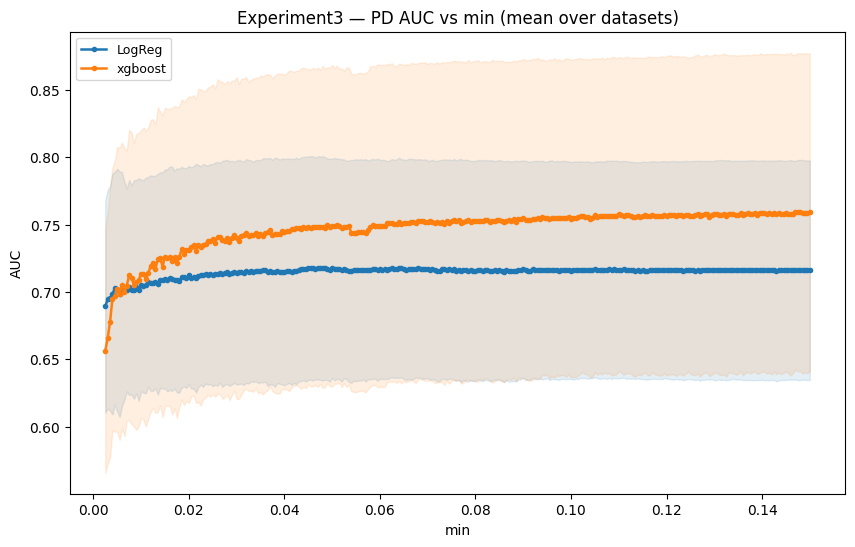

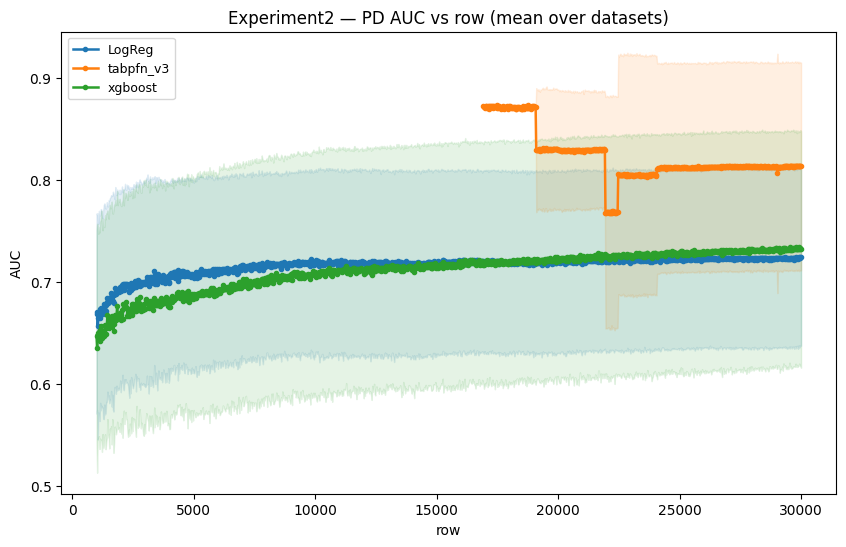

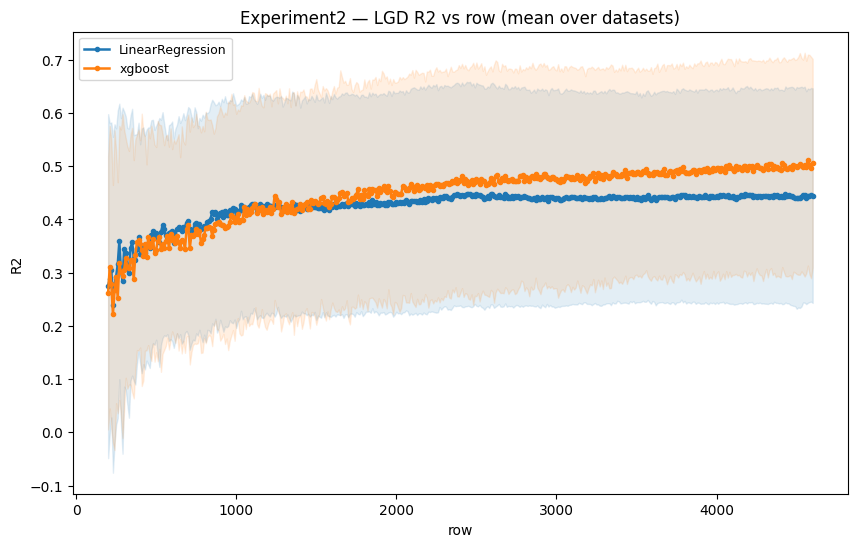

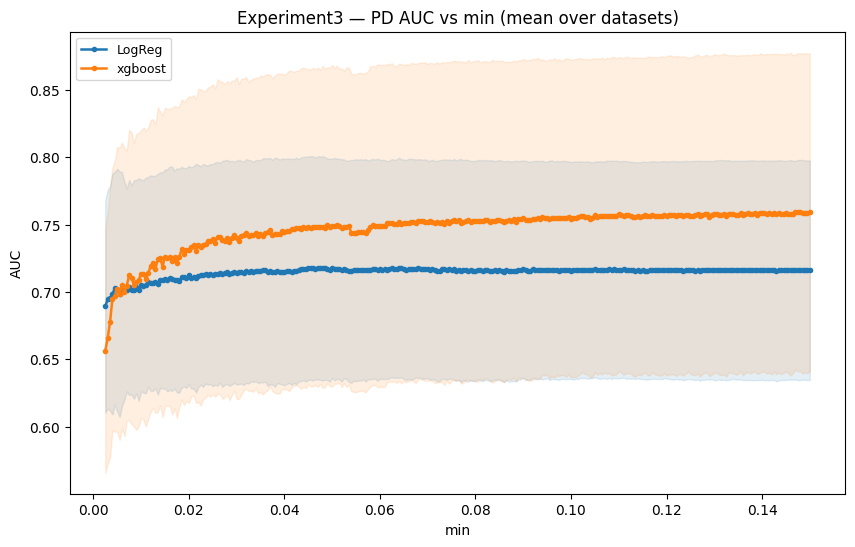

In [8]:
# Holes in a line reveal missing sweep points; band = +-1 std across datasets.
audit2 = rc.audit_experiment('Experiment2', results_root=RESULTS_ROOT)
rc.plot_sweep_curves(audit2, task='pd',  metric='AUC')
rc.plot_sweep_curves(audit2, task='lgd', metric='R2')
audit3 = rc.audit_experiment('Experiment3', results_root=RESULTS_ROOT)
rc.plot_sweep_curves(audit3, task='pd', metric='AUC')